[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/01_foundations/01_python_basics.ipynb)

# 📓 Notebook 1 — Python Basics for AI, Automation, and Business Data Science

> **Module:** Python Fundamentals · **Estimated time:** 30–40 min · **Difficulty:** Beginner

Welcome to the first notebook of the course. Before you can train a model, automate an inbox, or build a dashboard, you need fluency in the small things: storing values, doing arithmetic, formatting text. These look trivial but they are *most* of the code you will write in a real project.

**Our running project.** Rather than meet each tool in isolation, we'll spend the whole notebook building toward one concrete deliverable: a small **daily KPI report for an AI support bot** — the kind of thing you'd paste into a Slack channel each morning (*how many tickets did the bot answer, what did it cost, what was the ROI?*). Every section adds exactly the piece the report needs next — variables to hold the numbers, types to read them off an API, arithmetic to price the tokens, f-strings to format the lines — and in §8 it all snaps together. By the end you'll be able to write small, clean Python scripts that solve the bookkeeping problems that show up *every day* in AI-enabled work.

> 🧭 **One mental model, used throughout.** A variable is **an arrow (a name) pointing at an object** — *not* a box that holds a value. We build this picture in §2 and lean on it for the rest of the course; it's the single idea that later explains aliasing, mutation, and "why did my list change?!"

## 🎯 Learning objectives

After this notebook you can:

1. Run code in a Jupyter notebook and understand how execution order works.
2. Create variables of the five core types (`int`, `float`, `str`, `bool`, `None`).
3. Convert between types — the bread-and-butter of cleaning API and CSV data.
4. Do arithmetic correctly and know the difference between `/`, `//`, `%`, and `**`.
5. Manipulate text with string methods and **f-strings**.
6. Build a small, well-formatted report from raw numbers.
7. Recognise and fix the most common beginner errors.

## ✅ Prerequisites

None — you'll start from zero. The only requirement is the ability to type.

## 📚 How to study this notebook (and the rest of the course)

This course is designed for **self-study**. To get the most out of it:

1. **Read each section's prose first** — it explains *why*, not just *how*.
2. **Run every code cell** as you encounter it (Shift + Enter). Watch the output.
3. **Try each exercise yourself** before clicking the solution. Five minutes of
   genuine struggle beats five hours of passive reading.
4. **Tweak the code.** Change a number, predict the new output, re-run. That is
   the fastest way to build real fluency.
5. **Use the self-assessment checklist** at the end to decide if you are ready
   to move on. If a box won't tick, scroll back to the relevant section.

You don't need to memorise anything — the cheat sheets in the notebook will
still be here when you come back.


## 1. What is a Jupyter notebook?

A Jupyter notebook is an *interactive* document that interleaves **prose** and **executable code**. It is the universal lab journal of modern data and AI work:

- **Markdown cells** (like this one) hold your explanations, equations, and notes.
- **Code cells** hold Python you can execute by pressing **Shift + Enter** (or clicking ▶ in Colab).

Why this matters for AI work: every serious AI project starts with exploration — you load some data, you poke at it, you draft a prompt, you try a model, you tweak. A notebook keeps the question and the answer side-by-side, which is exactly what you need when you're figuring something out.

Run the cell below by clicking on it and pressing **Shift + Enter**.

In [1]:
# Anything after a "#" is a comment — Python ignores it.
# Comments are notes for your future self and your teammates.

print("Hello, Python! 🐍")
print("Welcome to AI-driven automation and business data science.")


Hello, Python! 🐍
Welcome to AI-driven automation and business data science.


You should see two lines printed below the cell.

> 💡 **Execution order matters, not cell order.** A notebook runs whichever cell you click on. If results look stale, choose **Runtime → Restart and run all** (Colab) or **Kernel → Restart & Run All** (Jupyter Lab) to start fresh.

## 2. Variables — naming pieces of data

Our KPI report will juggle a dozen numbers — a model name, a price, a token count, a flag for whether we're live. Without names, they'd be a soup of anonymous literals scattered through the code. A **variable** fixes that: it's a name you attach to a value so you can reuse it and *read* it. Think of variables, for now, as *labelled boxes*:

```
┌────────────────┐    ┌────────┐    ┌──────────┐
│ "gpt-4o-mini"  │    │ 0.0006 │    │ 14_500   │
└──────┬─────────┘    └───┬────┘    └────┬─────┘
       │                  │              │
    model_name      price_per_1k    monthly_tokens
```

You create a variable in Python with `=`. The one rule that pays for itself: pick a name that says *what the value means*, not what type it is. (We'll upgrade the "labelled box" picture in a moment — hold onto it for just a few cells.)

In [2]:
# A few values from a small AI automation project
model_name       = "gpt-4o-mini"   # which model we are calling
price_per_1k     = 0.0006           # USD per 1,000 input tokens
monthly_tokens   = 14_500_000       # tokens we expect to send each month
is_production    = True             # are we live or still prototyping?

# Display all four on aligned lines using f-strings (more on these later)
print(f"Model            : {model_name}")
print(f"Price / 1K tokens: ${price_per_1k}")
print(f"Tokens / month   : {monthly_tokens:,}")
print(f"In production?   : {is_production}")


Model            : gpt-4o-mini
Price / 1K tokens: $0.0006
Tokens / month   : 14,500,000
In production?   : True


> 💡 **Underscores in numbers.** Python lets you write `14_500_000` instead of `14500000` to make long numbers readable. They are exactly the same value — the underscores are just visual.

### Naming rules — and good style

Python is strict about *valid* names. The community is strict about *good* names.

| Rule                                                   | Example                            |
|--------------------------------------------------------|------------------------------------|
| Must start with a letter or `_`                        | `model_name`, `_tmp`               |
| Then letters, digits, underscores only                 | `model_v2`, `n_tokens_in`          |
| Case-sensitive                                         | `Price` ≠ `price`                  |
| Cannot use a Python keyword                            | not allowed: `class`, `return`, `if` |
| **Convention:** use `snake_case`                       | `monthly_tokens`, `is_production`  |

Bad names cost more debugging time than any other beginner habit:

| ❌ Don't                | ✅ Do                              |
|------------------------|-----------------------------------|
| `x = 14_500_000`       | `monthly_tokens = 14_500_000`     |
| `temp1 = "gpt-4o-mini"`| `model_name = "gpt-4o-mini"`      |
| `flag = True`          | `is_production = True`            |


### 🔬 What actually happens when you write `x = 5`

The *"labelled box"* picture above is a friendly first sketch — but it quietly suggests the wrong thing: that the variable **is** a box that **holds** the value, and that `=` **puts the value into the box**. Python does not work like that, and getting the real model straight now will save you from a whole family of confusing bugs in later notebooks (aliasing, mutation, "why did my list change?!").

Here is the truth in one sentence:

> **A variable is not a box that holds a value. It is a *name* that points at an *object* living somewhere in memory.**

So `model_name = "gpt-4o-mini"` is really two separate things that happen in order:

```text
Step 1 — build the object        Step 2 — bind the name to it

  "gpt-4o-mini"                     model_name ───▶ "gpt-4o-mini"
  ┌──────────────┐                      (a name)      (the object
  │ str object   │                                     in memory)
  │ id: 0x10a3f0 │
  └──────────────┘
```

1. **The value on the right is created first.** Python builds a `str` object `"gpt-4o-mini"` somewhere in memory. That object has an identity — a fixed address you can see with `id()`.
2. **Then `=` *binds* the name on the left to that object.** It does **not** copy the value into a box called `model_name`. It just makes `model_name` an *arrow* pointing at the object.

Read `=` not as *"equals"* but as **"is bound to the object on the right"**. Arrows, not boxes.


### Box thinking vs. name thinking

The difference looks academic until two names get involved — then it decides whether your code is correct.

| | "Box" mental model (informal) | **"Name → object"** model (how Python really works) |
|---|---|---|
| What a variable *is* | A container that stores a value | A **name** bound to an object |
| What `=` does | Copies the value into the box | **Binds** the name to the right-hand object |
| `b = a` means | Copy `a`'s contents into a second box | Make `b` a **second name for the same object** |
| Where the value lives | Inside the variable | In one place in memory; names just point at it |
| How to inspect it | — | `id(x)` (the address) and `x is y` (same object?) |

The two models agree right up until you write `b = a`. The box model says *"now there are two boxes, each with its own copy."* The real model says *"now there are two arrows pointing at the **one** object."* Let's prove which one is true.


In [3]:
# === Proof 1: `b = a` makes TWO NAMES for the SAME object ===
a = [10, 20, 30]      # build a list object; bind the name `a` to it
b = a                 # does NOT copy — binds `b` to the SAME object

print("a       :", a)
print("b       :", b)
print("id(a)   :", id(a))      # the memory address `a` points at
print("id(b)   :", id(b))      # ... identical! same object
print("a is b  :", a is b)     # `is` asks: SAME object?      -> True
print("a == b  :", a == b)     # `==` asks: equal VALUES?     -> True

# `is` vs `==` are different questions. Two DIFFERENT objects can be equal:
c = [10, 20, 30]               # a brand-new list, same contents
print("\nc = [10, 20, 30]  (a fresh, separate object)")
print("a == c  :", a == c)     # equal values?     -> True
print("a is c  :", a is c)     # the SAME object?  -> False  (different id)
print("id(c)   :", id(c), "  <- a different address from id(a)")


a       : [10, 20, 30]
b       : [10, 20, 30]
id(a)   : 4438076416
id(b)   : 4438076416
a is b  : True
a == b  : True

c = [10, 20, 30]  (a fresh, separate object)
a == c  : True
a is c  : False
id(c)   : 4438074880   <- a different address from id(a)


> 🎯 **Intuition — `is` vs `==`.** Think of objects as people.
> `a == c` asks *"do these two people have the same name and birthday?"* (equal **values**).
> `a is c` asks *"are these two arrows pointing at the **literally same person**?"* (same **identity**).
> Two different people can share a name and birthday (`==` is `True`) yet still be two separate people (`is` is `False`). In day-to-day code you almost always want `==`. Reserve `is` for the special singletons `None`, `True`, and `False` — e.g. `if result is None:`.


### Why `y = x; y += 1` leaves `x` unchanged — rebinding vs. mutation

Here is the classic puzzle this model exists to explain. Predict the final value of `x`:

```python
x = 5
y = x       # y now points at the SAME int object as x
y += 1      # ... so does x change too?
```

It feels like `y` and `x` are "linked", so bumping `y` might drag `x` along. They are **not** linked — and the reason is that integers are **immutable** (they can never be changed in place). Watch with `id()`:

```text
x = 5        x ─┐
                ├──▶  5      (one shared int object)
y = x        y ─┘

y += 1   →   there is no "+1 in place" for an int. Python BUILDS a NEW
             object 6, then REBINDS the name y to it. x is untouched:

             x ───────────▶  5      (still the original object)
             y ───────────▶  6      (a different, new object)
```

`y += 1` does **not** edit the object `5`. It computes `y + 1` → a *new* object `6`, and then **rebinds** `y` to that new object. The name `x` still points at the original `5`. The cell below proves every step with `id()`.


In [4]:
# === Proof 2: integers are immutable -> `+=` rebinds, it does not mutate ===
x = 5
y = x
print("After  y = x :")
print(f"  x = {x}, id(x) = {id(x)}")
print(f"  y = {y}, id(y) = {id(y)}")
print(f"  x is y -> {x is y}   (same object: y is just a 2nd name for 5)")

y += 1                      # builds a NEW int 6, rebinds y to it
print("\nAfter  y += 1 :")
print(f"  x = {x}, id(x) = {id(x)}   <- UNCHANGED, still the original 5")
print(f"  y = {y}, id(y) = {id(y)}   <- NEW object, different id")
print(f"  x is y -> {x is y}   (now two different objects)")

print(f"\nFinal answer:  x = {x}   (rebinding y never touched x)")


After  y = x :
  x = 5, id(x) = 4340369984
  y = 5, id(y) = 4340369984
  x is y -> True   (same object: y is just a 2nd name for 5)

After  y += 1 :
  x = 5, id(x) = 4340369984   <- UNCHANGED, still the original 5
  y = 6, id(y) = 4340370016   <- NEW object, different id
  x is y -> False   (now two different objects)

Final answer:  x = 5   (rebinding y never touched x)


### 🖼️ Names and objects, drawn

The two proofs above as one picture. **Left:** `b = a` doesn’t copy — both names point at the *same* list, so `a is b` is `True`. **Right:** `y += 1` can’t change the shared `5` (ints are immutable), so it builds a **new** `6` and re-points only `y` — `x` is untouched.

> 💡 **How to read it.** A boxed letter is a **name**; an arrow is the binding “points at”; a rounded box is an **object** in memory. Assignment moves an *arrow*, never the object.

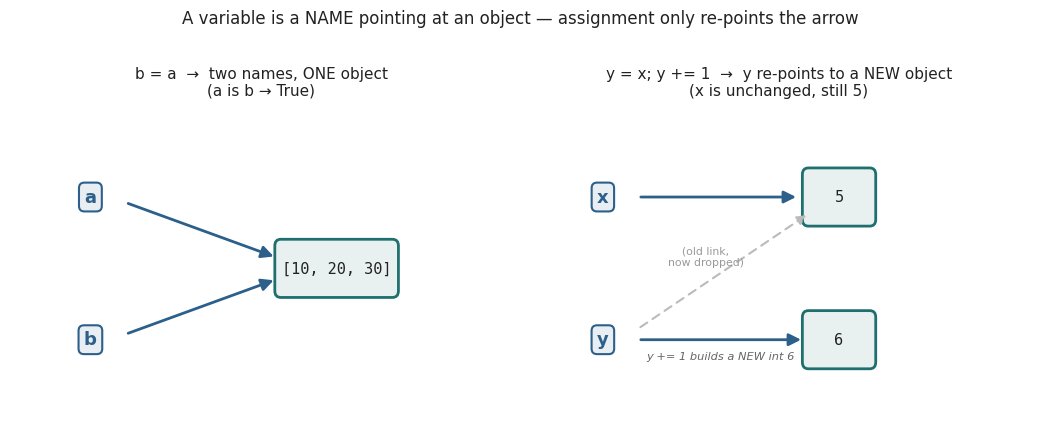

In [5]:
# Variables are NAMES (arrows) pointing at objects. `=` only ever re-points an arrow.
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

NAME, OBJ, OLD = "#2C5F8A", "#1F6F6F", "#bbbbbb"
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))

def name_tag(ax, x, y, label, color=NAME):
    ax.text(x, y, label, fontsize=13, fontweight="bold", color=color,
            ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.3", fc=color + "1A", ec=color, lw=1.5))

def obj_box(ax, cx, y, text, color=OBJ, w=2.4, h=1.0):
    ax.add_patch(FancyBboxPatch((cx - w/2, y - h/2), w, h,
        boxstyle="round,pad=0.03,rounding_size=0.12",
        linewidth=2, edgecolor=color, facecolor=color + "1A"))
    ax.text(cx, y, text, ha="center", va="center", fontsize=11,
            family="monospace", color="#222222")

# ---- Panel A: aliasing — b = a -> two names, ONE object ----
a = axes[0]; a.set_xlim(0, 10); a.set_ylim(0, 6); a.axis("off")
name_tag(a, 1.6, 4.3, "a"); name_tag(a, 1.6, 1.7, "b")
obj_box(a, 6.5, 3.0, "[10, 20, 30]")
a.add_patch(FancyArrowPatch((2.3, 4.2), (5.3, 3.2), arrowstyle="-|>", mutation_scale=18, lw=2, color=NAME))
a.add_patch(FancyArrowPatch((2.3, 1.8), (5.3, 2.8), arrowstyle="-|>", mutation_scale=18, lw=2, color=NAME))
a.set_title("b = a  →  two names, ONE object\n(a is b → True)", fontsize=11, color="#222222")

# ---- Panel B: rebinding — y = x; y += 1 ----
b = axes[1]; b.set_xlim(0, 10); b.set_ylim(0, 6); b.axis("off")
name_tag(b, 1.5, 4.3, "x"); name_tag(b, 1.5, 1.7, "y")
obj_box(b, 6.2, 4.3, "5", w=1.4)
obj_box(b, 6.2, 1.7, "6", w=1.4)
b.add_patch(FancyArrowPatch((2.2, 4.3), (5.4, 4.3), arrowstyle="-|>", mutation_scale=18, lw=2, color=NAME))
# old (faded, crossed) arrow y -> 5, then new solid y -> 6
b.add_patch(FancyArrowPatch((2.2, 1.9), (5.6, 4.0), arrowstyle="-|>", mutation_scale=14, lw=1.5,
            color=OLD, linestyle=(0, (4, 3))))
b.text(3.55, 3.05, "(old link,\nnow dropped)", fontsize=7.8, color="#999999", ha="center")
b.add_patch(FancyArrowPatch((2.2, 1.7), (5.5, 1.7), arrowstyle="-|>", mutation_scale=18, lw=2, color=NAME))
b.text(3.85, 1.35, "y += 1 builds a NEW int 6", fontsize=8.2, style="italic", color="#666666", ha="center")
b.set_title("y = x; y += 1  →  y re-points to a NEW object\n(x is unchanged, still 5)", fontsize=11, color="#222222")

fig.suptitle("A variable is a NAME pointing at an object — assignment only re-points the arrow",
             fontsize=12, color="#222222", y=1.02)
plt.tight_layout()
plt.show()


> 🧠 **The mental model to keep for the whole course.** Every variable is an **arrow (a name) pointing at an object** — exactly the picture we promised in the intro. Assignment (`=`) only ever **re-points an arrow**; it never copies the object and never reaches "through" one name to change another. With **immutable** types (`int`, `float`, `str`, `bool`, `None`, `tuple`) you literally *cannot* change the object, so operations like `+=` always build a new object and re-point the name. That is exactly why `x` survived above — and you'll reach for this picture again the moment we start formatting numbers, because strings are immutable too.

> 🔭 **Forward-reference.** The story has a famous twist for **mutable** objects (lists, dicts, sets). There, `b = a` still makes two names for *one* object — but because the object *can* be changed in place, mutating it *through `b`* is visible *through `a`* too. That's **aliasing**, the single most common source of "but I never touched that variable!" bugs. You'll meet it head-on in **NB 3 (Lists & Data Structures)** and **NB 4 (Dictionaries)**. The arrow model you just learned is the key that unlocks it — keep it close.


## 3. F-strings — formatting reports and prompts

We can now *store* the report's numbers (§2). But storing them isn't the deliverable — a human has to *read* them. Try printing a raw price and you'll see the problem: `14823.4567` is technically correct and completely unreadable. No currency symbol, no thousands separator, no alignment. Stick a few of those in a report and nobody trusts it.

**F-strings** are the fix. They're the modern way (Python 3.6+) to build strings that splice in variable values *and* format them on the spot. They start with the letter `f` and use `{ ... }` to embed expressions:

```
f"... {expression:format_spec} ..."
```

The `:format_spec` part is optional but it's where the magic lives — it turns `14823.4567` into `€14,823.46`. (And the very same syntax builds *prompts* for LLMs later in the course.)

> 🔭 **Forward-reference.** The example below uses *floats* (`14823.4567`) and a bit of *arithmetic* (`mrr * 12`) — the next two sections of this notebook. For now just follow the f-string structure; the surrounding values will make complete sense within ten minutes.


In [6]:
customer = "Acme Inc."
mrr      = 14823.4567        # monthly recurring revenue
churn    = 0.04287           # 4.287%
arr      = mrr * 12

# Basic embedding
print(f"Hello, {customer}!")

# Two decimal places, currency-style with thousands separator
print(f"MRR  : €{mrr:>12,.2f}")
print(f"ARR  : €{arr:>12,.2f}")

# As a percentage (multiplies by 100, adds %, one decimal)
print(f"Churn: {churn:>12.1%}")

# A clean tabular line: name left-aligned, numbers right-aligned
print(f"\n|{'Customer':<12}|{'MRR (€)':>12}|{'Churn':>8}|")
print(f"|{customer:<12}|{mrr:>12,.2f}|{churn:>8.1%}|")


Hello, Acme Inc.!
MRR  : €   14,823.46
ARR  : €  177,881.48
Churn:         4.3%

|Customer    |     MRR (€)|   Churn|
|Acme Inc.   |   14,823.46|    4.3%|


### Format spec cheat sheet

| Spec        | Meaning                                | Example          | Output           |
|-------------|----------------------------------------|------------------|------------------|
| `:.2f`      | fixed-point, 2 decimals                | `f"{3.14159:.2f}"` | `3.14`           |
| `:.4f`      | fixed-point, 4 decimals                | `f"{0.00057:.4f}"` | `0.0006`         |
| `:.1%`      | percentage, 1 decimal                  | `f"{0.873:.1%}"`   | `87.3%`          |
| `:,`        | thousands separator                    | `f"{1234567:,}"`   | `1,234,567`      |
| `:,.2f`     | thousands separator + 2 decimals       | `f"{1234.5:,.2f}"` | `1,234.50`       |
| `:>10`      | right-align in width 10                | `f"|{'x':>10}|"`   | ``|         x|`` |
| `:<10`      | left-align in width 10                 | `f"|{'x':<10}|"`   | `` |x         |``|
| `:^10`      | center in width 10                     | `f"|{'x':^10}|"`   | `` |    x     |``|
| `:e`        | scientific notation                    | `f"{0.000057:.2e}"`| `5.70e-05`       |

These look like trivia, but spend two hours building a status report by hand and you will memorise them in self-defence.

---

### ✋ Quick exercise (~2 min) — Format a one-line status

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

You're given three values from a model deployment. Print them as **one** clean line using a single f-string:

```python
model = "claude-haiku-4-5"
price = 0.0008      # USD per 1K tokens
share = 0.732       # fraction of traffic on this model
```

Target output:

```
claude-haiku-4-5 · $0.0008/1K · 73.2% of traffic
```

Use `:.4f` for the price and `:.1%` for the share.

In [7]:
# ✍️ Your turn 👇
model = "claude-haiku-4-5"
price = 0.0008      # USD per 1K tokens
share = 0.732       # fraction of traffic on this model

# Print one line:  claude-haiku-4-5 · $0.0008/1K · 73.2% of traffic


<details>
<summary>✅ <b>Solution</b></summary>

```python
print(f"{model} · ${price:.4f}/1K · {share:.1%} of traffic")
```

One f-string, three fields. `:.4f` keeps four decimals on the price; `:.1%` multiplies the share by 100 and appends `%`. No string concatenation, no `str()` calls.
</details>

## 4. Core data types

We've been writing numbers, text, and `True` without naming what they *are*. That works until something goes wrong — and with real data, something always does. The report's token count might arrive as the string `"1320500"` instead of the number `1320500`, and the two behave completely differently. To debug that, you need to know what *kind* of value you're holding.

There are five basic types you'll meet over and over in AI and business code:

| Type     | Python name | Example          | Used for                                       |
|----------|-------------|------------------|------------------------------------------------|
| Integer  | `int`       | `42`             | counts, IDs, token counts                       |
| Float    | `float`     | `0.0006`         | prices, probabilities, model scores             |
| String   | `str`       | `"gpt-4o-mini"`  | identifiers, prompts, responses, file paths     |
| Boolean  | `bool`      | `True`, `False`  | flags, conditions, on/off switches              |
| None     | `NoneType`  | `None`           | "no value yet" — common for optional results    |

Use `type()` to ask Python what kind of value something is.

> 🚫 **Misconception — "`is` checks whether two values are equal."**
> `is` checks **identity** (are these the *same object* in memory?), not equality. Use `==` to compare *values* and `is` only to compare against singletons like `None` (`if x is None:`). `1000 == 1000` is always `True`, but `1000 is 1000` can be `False` because Python may build two separate `int` objects. Rule: **`==` for values, `is` for `None`.**


In [8]:
# A toy "API response" we just received from an LLM service
request_id    = 9_472_193        # an integer ID
latency_s     = 1.84             # a float (decimal)
status        = "completed"      # a string
was_cached    = False            # a boolean
error_detail  = None             # we have no error → None

# Print each value alongside its type. `type(x).__name__` is just
# Python's way of asking 'what kind of thing is this?' — we'll
# come back to it later. For now: notice the names on the right.
print(request_id,    "->", type(request_id).__name__)     # int
print(latency_s,     "->", type(latency_s).__name__)      # float
print(status,        "->", type(status).__name__)         # str
print(was_cached,    "->", type(was_cached).__name__)     # bool
print(error_detail,  "->", type(error_detail).__name__)   # NoneType


9472193 -> int
1.84 -> float
completed -> str
False -> bool
None -> NoneType


### Why this matters for AI / business data

When you pull data from an API or load a CSV, **almost everything arrives as a string** — even if it *looks* like a number. A token count of `"1024"` (a string) is not the same as `1024` (an int) and you can't do arithmetic with the string version. So *the very first thing* you do with real data is type-conversion.

You convert with `int()`, `float()`, `str()`, `bool()`:

In [9]:
# From an API response, fields often arrive as strings:
raw_tokens_in_str = "1024"          # came back as a string
raw_tokens_in     = int(raw_tokens_in_str)
print(f"As text   : {raw_tokens_in_str!r}  (type {type(raw_tokens_in_str).__name__})")
print(f"As int    : {raw_tokens_in}     (type {type(raw_tokens_in).__name__})")

# From int to float — needed when computing a per-token price
print(f"\nAs float  : {float(raw_tokens_in)}  (type {type(float(raw_tokens_in)).__name__})")

# Cast a float back to int — note the truncation, NOT rounding
print(f"int(3.9)  = {int(3.9)}   <- truncates toward zero (NOT rounding!)")
print(f"int(-3.9) = {int(-3.9)}  <- also truncates toward zero")

# When you actually want rounding, use round()
print(f"round(3.9)= {round(3.9)}")


As text   : '1024'  (type str)
As int    : 1024     (type int)

As float  : 1024.0  (type float)
int(3.9)  = 3   <- truncates toward zero (NOT rounding!)
int(-3.9) = -3  <- also truncates toward zero
round(3.9)= 4


> ⚠️ **Common pitfall.** `int(3.9)` is `3`, not `4`. Python truncates toward zero. Use `round()` if you want rounding, and `math.floor` / `math.ceil` if you want a specific direction.

> 💡 **Trick:** Pass `repr(value)` to `print` when you want to *see* what type a value is — strings will show their quotes, `None` will show as `None`, and so on.

## 5. Arithmetic — pricing AI workloads

Now we can store the report's inputs (§2), read them off an API in the right type (§4), and format them cleanly (§3). But the most useful lines in any KPI report aren't the raw inputs — they're the *derived* numbers: total cost, cost per ticket, ROI. Those come from arithmetic.

Python supports the operators you already know, plus a couple that show up constantly in data work:

| Operator | Meaning              | Example         | Result   |
|----------|----------------------|-----------------|----------|
| `+`      | addition             | `7 + 3`         | `10`     |
| `-`      | subtraction          | `7 - 3`         | `4`      |
| `*`      | multiplication       | `7 * 3`         | `21`     |
| `/`      | division (float)     | `7 / 2`         | `3.5`    |
| `//`     | floor division       | `7 // 2`        | `3`      |
| `%`      | remainder (modulo)   | `7 % 2`         | `1`      |
| `**`     | power                | `2 ** 10`       | `1024`   |

Two operators in particular pull their weight every day:

- `//` (**floor division**) is great when you want a count — *"how many full batches of 100 fit in 350?"* → `350 // 100 == 3`.
- `%` (**modulo**) tells you the remainder — *"is this an even row?"* → `i % 2 == 0`.

In [10]:
# Calling an LLM API on a batch of customer-support tickets
n_tickets        = 350                    # how many tickets to process
tokens_per_call  = 600                    # average tokens per ticket
price_per_1k_tok = 0.0006                 # USD

# Total tokens, total cost
total_tokens = n_tickets * tokens_per_call
total_cost   = total_tokens / 1000 * price_per_1k_tok
cost_per_t   = total_cost / n_tickets

print(f"Total tokens   : {total_tokens:,}")
print(f"Total cost     : ${total_cost:.4f}")
print(f"Cost / ticket  : ${cost_per_t:.5f}")

# Sending the batch in chunks of 100 — how many full chunks, how many left over?
chunk_size = 100
full_chunks = n_tickets // chunk_size      # floor division
leftover    = n_tickets %  chunk_size      # remainder
print(f"\nBatches of {chunk_size}: {full_chunks} full + {leftover} leftover")


Total tokens   : 210,000
Total cost     : $0.1260
Cost / ticket  : $0.00036

Batches of 100: 3 full + 50 leftover


### Operator precedence — just like in maths

`*` and `/` bind tighter than `+` and `-`. When in doubt — and especially in business arithmetic where one missing pair of parentheses can move a decimal — **use parentheses**. They cost nothing and they make intent explicit.

In [11]:
# These two are NOT the same!
print("2 + 3 * 4   =", 2 + 3 * 4)       # 14, because * goes first
print("(2 + 3) * 4 =", (2 + 3) * 4)     # 20

# A more realistic case: gross-to-net revenue with VAT
gross    = 1190
vat_rate = 0.19

# Without parentheses, Python would compute  gross / 1 + vat_rate  = 1190.19  (wrong!)
# With parentheses, we get  gross / (1 + 0.19) = 1000.00  (correct)
net_wrong   = gross / 1 + vat_rate              # ❌ 1190.19
net_correct = gross / (1 + vat_rate)            # ✅ 1000.00
print(f"Without parens : €{net_wrong:,.2f}")
print(f"With parens    : €{net_correct:,.2f}")


2 + 3 * 4   = 14
(2 + 3) * 4 = 20
Without parens : €1,190.19
With parens    : €1,000.00


---

### ✋ Quick exercise (~2 min) — Price a batch job

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

You'll send **3,200** support tickets to an LLM. Each ticket averages **750** tokens, and tokens cost **$0.0006 / 1K**.

Compute and print:

1. the **total cost** (`$`, 2 decimals), and
2. the **cost per ticket** (`$`, 5 decimals).

In [12]:
# ✍️ Your turn 👇
n_tickets       = 3_200
tokens_per_call = 750
price_per_1k    = 0.0006

# ...


<details>
<summary>✅ <b>Solution</b></summary>

```python
total_tokens = n_tickets * tokens_per_call
total_cost   = total_tokens / 1000 * price_per_1k
per_ticket   = total_cost / n_tickets

print(f"Total cost  : ${total_cost:.2f}")
print(f"Per ticket  : ${per_ticket:.5f}")
```

Tokens → thousands of tokens (`/ 1000`) → multiply by the per-1K price. Same three-layer shape as §5: inputs, derived values, formatted output.
</details>

## 6. Strings — the universal data type

Notice a pattern in the last few sections: every input to our report *arrived as text* — the model name, the currency code, the status field. That's not a coincidence. *Most* of what reaches you from an API, a CSV, or a user is a string, and it's usually a little dirty: stray whitespace, mixed case, a value glued together with separators. Before you can trust it, you have to clean it.

That cleaning is what string *methods* are for: customer names, product IDs, model identifiers, prompts, file paths, log lines — all of it is text you reshape with a handful of methods.

In [13]:
customer_id   = "C-00482"
product_sku   = "SKU-3491-RED"
support_email = "Help@Example.COM"

# Length
print(f"Customer ID length : {len(customer_id)}")

# Case methods — they return NEW strings (the original is unchanged)
print(f"Email lowered      : {support_email.lower()}")
print(f"SKU split on '-'   : {product_sku.split('-')}")

# Strip whitespace — vital when reading CSV cells
messy = "   gpt-4o-mini  \n"
print(f"Cleaned model name : {messy.strip()!r}")


Customer ID length : 7
Email lowered      : help@example.com
SKU split on '-'   : ['SKU', '3491', 'RED']
Cleaned model name : 'gpt-4o-mini'


> 💡 **Strings are immutable.** `email.lower()` does not modify `email`; it returns a new string. If you want the lowered version to stick, assign it back: `email = email.lower()`.

### A small, real toolbox

These string methods come up *constantly*:

| Method              | What it does                                | Example                              |
|---------------------|---------------------------------------------|--------------------------------------|
| `s.lower()`         | lowercase copy                              | `"AB".lower()` → `"ab"`              |
| `s.upper()`         | uppercase copy                              | `"ab".upper()` → `"AB"`              |
| `s.strip()`         | drop leading/trailing whitespace            | `"  hi  ".strip()` → `"hi"`          |
| `s.startswith(p)`   | does it start with `p`?                     | `"SKU-3491".startswith("SKU")` → `True` |
| `s.endswith(p)`     | does it end with `p`?                       | `"data.csv".endswith(".csv")` → `True` |
| `s.replace(a, b)`   | replace `a` with `b`                        | `"v1.0".replace(".", "-")` → `"v1-0"` |
| `s.split(sep)`      | break into a list at `sep`                  | `"a,b,c".split(",")` → `["a","b","c"]` |
| `sep.join(parts)`   | the inverse of split                        | `",".join(["a","b","c"])` → `"a,b,c"` |
| `s in t`            | substring test                              | `"@" in "x@y"` → `True`              |


---

### ✋ Quick exercise (~2 min) — Clean a messy field

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

A CSV cell arrived dirty:

```python
raw = "  Help@Example.COM \n"
```

Produce the clean, lowercase address `"help@example.com"` (no surrounding whitespace), then print whether it ends with `".com"`.

In [14]:
# ✍️ Your turn 👇
raw = "  Help@Example.COM \n"

# ...


<details>
<summary>✅ <b>Solution</b></summary>

```python
email = raw.strip().lower()
print(email)                    # help@example.com
print(email.endswith(".com"))   # True
```

Method calls *chain* left-to-right: `.strip()` removes the surrounding whitespace and newline, then `.lower()` normalises the case. Strings are immutable, so each call returns a *new* string — assign the result to keep it.
</details>

## 7. Updating variables — the accumulator pattern

Our report processes the day's tickets in *batches*, and we want the running cost as we go. That means starting a total at zero and adding to it — the single most common pattern in data work. Python has a clean shorthand for it: the *augmented assignment* operators (`+=`, `*=`, …).

(Watch closely with the arrow model from §2: `total_cost += 0.21` doesn't edit the old float in place — floats are immutable — it computes a new value and re-points the name. The accumulator *looks* like mutation, but it's really repeated rebinding.)

In [15]:
# Tally the cost of processing 3 batches of LLM calls
total_cost = 0.0
print(f"Start            : ${total_cost:.4f}")

total_cost += 0.21        # batch 1     (same as: total_cost = total_cost + 0.21)
total_cost += 0.18        # batch 2
total_cost += 0.27        # batch 3

print(f"After 3 batches  : ${total_cost:.4f}")

# Other augmented assignments
counter = 1
counter *= 2            # counter = counter * 2
counter *= 2
counter *= 2
print(f"After 3 doublings: {counter}")     # 8


Start            : $0.0000
After 3 batches  : $0.6600
After 3 doublings: 8


## 8. Applied example — the daily KPI report, at last

This is the deliverable we've been building toward since the intro. Look back at what each section gave us: **named variables** (§2) for the inputs, the right **types** (§4) so the maths works, **arithmetic** (§5) for the derived KPIs, and **f-strings** (§3) to lay it out so a human can read it at a glance. Put them together and the report writes itself.

The team wants a small daily snapshot that says, in plain English, how many tickets the bot answered, what it cost, and what the ROI was.

In [16]:
# === Daily numbers ===
tickets_total      = 1_284         # total tickets received today
tickets_auto       = 943           # tickets answered by the bot, no human
tokens_used        = 1_320_500     # input + output tokens consumed
price_per_1k_tok   = 0.0006        # USD per 1K tokens
human_cost_avoided = 312.40        # USD — estimated savings vs. human

# === Derived KPIs ===
auto_rate    = tickets_auto / tickets_total
llm_cost     = tokens_used / 1000 * price_per_1k_tok
roi          = (human_cost_avoided - llm_cost) / llm_cost

# === Report ===
print(f"📊 Daily AI Support Bot — KPI Snapshot")
print(f"-" * 42)
print(f"Tickets total     : {tickets_total:>10,}")
print(f"Auto-resolved     : {tickets_auto:>10,}  ({auto_rate:.1%})")
print(f"Tokens used       : {tokens_used:>10,}")
print(f"LLM cost          : ${llm_cost:>9.2f}")
print(f"Cost avoided      : ${human_cost_avoided:>9.2f}")
print(f"ROI               : {roi:>10.1f}x")


📊 Daily AI Support Bot — KPI Snapshot
------------------------------------------
Tickets total     :      1,284
Auto-resolved     :        943  (73.4%)
Tokens used       :  1,320,500
LLM cost          : $     0.79
Cost avoided      : $   312.40
ROI               :      393.3x


**Read that script carefully — it's the shape of every data script you'll ever write:**

1. **Inputs** at the top — clearly named (§2), easy to change.
2. **Derived values** computed once (§5), with descriptive names.
3. **Output** formatted (§3) so a human reads it without further interpretation.

If the price ever changes, you edit one number and rerun; the rest is automatic. That is the entire point of writing Python instead of using a calculator — and it's why we kept the inputs, the maths, and the formatting as three clean layers all the way through.

## 9. Common pitfalls

Spotting these now will save you hours of debugging later.

1. **Text vs. number.** `"25"` is a string, `25` is an integer. `"25" + 5` raises a `TypeError`. Convert first: `int("25") + 5`.
2. **Integer vs. float division.** `5 / 2` → `2.5`. `5 // 2` → `2`. Choose deliberately.
3. **Strings are immutable.** `name.upper()` returns a new string. Assign it back: `name = name.upper()`.
4. **Floating-point surprises.** `0.1 + 0.2` is not exactly `0.3`. Compare with a tolerance, not `==`, when you care.
5. **Truncation, not rounding.** `int(3.9)` is `3`. Use `round()` when you want 4.

In [17]:
# Pitfall 2: float vs floor division
print("5 / 2  =", 5 / 2)      # 2.5
print("5 // 2 =", 5 // 2)     # 2

# Pitfall 4: floating-point surprises
a, b = 0.1 + 0.2, 0.3
print(f"\n0.1 + 0.2 = {a!r}")
print(f"is it == 0.3?  {a == b}")
print(f"close enough?  {abs(a - b) < 1e-9}")

# Pitfall 1: TypeError from mixing types
try:
    "25" + 5
except TypeError as e:
    print(f"\nTypeError caught: {e}")


5 / 2  = 2.5
5 // 2 = 2

0.1 + 0.2 = 0.30000000000000004
is it == 0.3?  False
close enough?  True

TypeError caught: can only concatenate str (not "int") to str


## 🔮 Predict-the-output exercise

The fastest way to test your mental model: **predict what the cell prints _before_ you run it.**

### 🔮 Predict the output

```python
print(7 / 2)     # true division
print(7 // 2)    # floor division
print(7 % 2)     # remainder
print(7.0 // 2)  # floor division with a float
```

Four lines. Which results are `int`s, which are `float`s, and what are the values? Predict, then run.


In [18]:
print(7 / 2)     # true division
print(7 // 2)    # floor division
print(7 % 2)     # remainder
print(7.0 // 2)  # floor division with a float


3.5
3
1
3.0


<details>
<summary>💡 <b>Answer</b></summary>

`3.5`, `3`, `1`, `3.0`. Plain `/` **always** returns a `float` (so `7 / 2` is `3.5`, never `3`). `//` is _floor_ division — it rounds **down** to the nearest whole number, so `7 // 2` is `3`. `%` gives the remainder, `1`. The last surprises people: `7.0 // 2` still floors, but because one operand is a `float`, the result keeps the float type → `3.0`, not `3`.
</details>


## 🧪 Practice exercises

Try each exercise yourself first. Solutions are right below — but you learn while struggling, not while reading the answer.

### Exercise 1 — ⭐ Personal "data card"

Create variables for your **name**, your **role** (e.g. `"Data Analyst"`), and the **number of dashboards** you currently maintain. Print them in a single sentence:

> *"Hi, I'm Alice, a Data Analyst, and I currently maintain 4 dashboards."*

In [19]:
# Your code here  👇
my_name      = "Alice"
my_role      = "Data Analyst"
my_dashboards = 4

# ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
my_name       = "Alice"
my_role       = "Data Analyst"
my_dashboards = 4

print(f"Hi, I'm {my_name}, a {my_role}, and I currently maintain {my_dashboards} dashboards.")
```

**Reasoning.** We use one f-string and embed each variable in place. Notice how readable the line is — embedding values directly is much clearer than `print("Hi, I'm " + my_name + ...)`.
</details>

### Exercise 2 — ⭐⭐ LLM cost calculator

You are about to run an LLM on **2,450** customer reviews. Each call uses about **450** input tokens and **120** output tokens. Input tokens cost **$0.0006 / 1K**, output tokens cost **$0.0024 / 1K**.

Print:

1. the total number of input and output tokens,
2. the total cost (4 decimals, dollars),
3. the average cost per review (5 decimals).

In [20]:
# Your code here  👇
n_reviews       = 2_450
input_per_call  = 450
output_per_call = 120
in_price_per_k  = 0.0006     # USD / 1K input tokens
out_price_per_k = 0.0024     # USD / 1K output tokens

# ...


<details>
<summary>💡 <b>Solution</b></summary>

```python
n_reviews       = 2_450
input_per_call  = 450
output_per_call = 120
in_price_per_k  = 0.0006
out_price_per_k = 0.0024

total_input  = n_reviews * input_per_call
total_output = n_reviews * output_per_call

input_cost   = total_input  / 1000 * in_price_per_k
output_cost  = total_output / 1000 * out_price_per_k
total_cost   = input_cost + output_cost
per_review   = total_cost / n_reviews

print(f"Total input tokens : {total_input:,}")
print(f"Total output tokens: {total_output:,}")
print(f"Input cost         : ${input_cost:.4f}")
print(f"Output cost        : ${output_cost:.4f}")
print(f"Total              : ${total_cost:.4f}")
print(f"Per review         : ${per_review:.5f}")
```

**Reasoning.** Each block of the calculation lives on its own line with a descriptive name. If a price changes you edit one number; nothing else needs to be touched. This is the pattern that scales from a notebook to a production script.
</details>

### Exercise 3 — ⭐⭐ Parsing a "stringly typed" API field

An API returned you the following raw values **as strings**:

```python
raw_price    = "1199.95"
raw_quantity = "  42 "
raw_currency = "eur"
```

Convert them to the right types and compute the **total value** of the order. Print it as `"Order total: €50,397.90"` (note the formatting — currency symbol, thousands separator, two decimals).

In [21]:
# Your code here  👇
raw_price    = "1199.95"
raw_quantity = "  42 "
raw_currency = "eur"

# ...


<details>
<summary>💡 <b>Solution</b></summary>

```python
raw_price    = "1199.95"
raw_quantity = "  42 "
raw_currency = "eur"

# Clean and convert
price    = float(raw_price)
quantity = int(raw_quantity.strip())
symbol   = "€" if raw_currency.strip().lower() == "eur" else "$"

total = price * quantity
print(f"Order total: {symbol}{total:,.2f}")
```

**Reasoning.** Three habits to internalise right now:

1. **Strip whitespace before converting.** `int()` happens to tolerate surrounding spaces, but an explicit `.strip()` makes the cleaning step visible — and it protects you once the field contains other stray characters.
2. **`float()` for prices**, `int()` for counts.
3. **Normalise text fields with `.lower()`** before comparing them.
</details>

### Exercise 4 — ⭐⭐ Debug me 🐞

The cell below contains **three bugs**. Read it carefully, predict what will happen, then fix the bugs so it prints a sensible message.

In [22]:
# ⚠️ THIS CELL INTENTIONALLY ERRORS. Read the markdown above — it's the puzzle.
# Buggy code — fix the three bugs!
revenue = "1200"
costs   = 800
profit  = revenue - costs
margin  = profit / revenue
print("Profit: " + profit + ", margin: " + margin)


TypeError: unsupported operand type(s) for -: 'str' and 'int'

<details>
<summary>💡 <b>Solution</b></summary>

The three bugs are:

1. `revenue = "1200"` — that is a *string*, not a number, so the subtraction fails. Either write `revenue = 1200` or convert with `int(revenue)`.
2. `"Profit: " + profit` — you cannot concatenate a string with a number. Use an f-string instead.
3. Same issue with `margin`. While we are there, format `margin` as a percentage.

```python
revenue = 1200             # was: "1200"
costs   = 800

profit  = revenue - costs
margin  = profit / revenue

print(f"Profit: €{profit:,.2f}, margin: {margin:.1%}")   # → Profit: €400.00, margin: 33.3%
```
</details>

## 🧠 Stretch exercises

Two more applied exercises to deepen the material. Try them yourself before opening the solution.


### Stretch exercise A — ⭐⭐⭐ Monthly cost with compounding growth

A new AI feature starts at **2,000 calls / month**. Volume grows **6% month-over-month**. Each call costs **$0.0012** on average. Compute and print:

1. The volume in month 6 and month 12.
2. The total spend across the *full first year* (sum of all 12 months).
3. The average cost per month over that year.

Format dollars with two decimals and thousands separators.


In [23]:
# Your code here  👇
start_calls   = 2_000
growth        = 0.06
cost_per_call = 0.0012
months        = 12


<details>
<summary>💡 <b>Solution</b></summary>

```python
start_calls, growth, cost_per_call, months = 2_000, 0.06, 0.0012, 12
total_calls = sum(start_calls * (1 + growth) ** m for m in range(months))
month6  = start_calls * (1 + growth) ** 5     # month 6 → index 5
month12 = start_calls * (1 + growth) ** 11
total_spend = total_calls * cost_per_call
avg_month   = total_spend / months

print(f"Volume month 6  : {month6:>10,.0f}")
print(f"Volume month 12 : {month12:>10,.0f}")
print(f"Total spend     : ${total_spend:>10,.2f}")
print(f"Average / month : ${avg_month:>10,.2f}")
```

**Reasoning.** Use a generator inside `sum()` to keep the code one line.
Indices start at 0 → month 6 is `**5`, month 12 is `**11`. The same
shape (inputs at the top, derived values, formatted output) you'll
use in every script for the rest of the course.

</details>

### Stretch exercise B — ⭐⭐⭐ Pretty-print a transaction record

You receive this transaction record:

```python
txn = {"id": "T-9472", "amount_cents": 134950, "currency": "eur",
       "customer": "Acme Inc.", "discount_pct": 0.085}
```

Print exactly one line like:

    T-9472  Acme Inc.            €1,349.50  (-8.5% disc, net €1,234.79)

> 🔭 **Forward-reference.** `txn` is a *dictionary* — properly introduced in **NB 4**. For now, read `txn["amount_cents"]` as "the value stored under that name".

Notes: the amount comes in *cents*; the currency must be normalised to a symbol; the customer name is left-aligned in width 20.


In [24]:
# Your code here  👇
txn = {"id": "T-9472", "amount_cents": 134950, "currency": "eur",
       "customer": "Acme Inc.", "discount_pct": 0.085}


<details>
<summary>💡 <b>Solution</b></summary>

```python
gross  = txn["amount_cents"] / 100
net    = gross * (1 - txn["discount_pct"])
symbol = {"eur": "€", "usd": "$", "gbp": "£"}.get(txn["currency"].lower(), txn["currency"])

print(f'{txn["id"]}  {txn["customer"]:<20}'
      f' {symbol}{gross:,.2f}  '
      f'(-{txn["discount_pct"]:.1%} disc, net {symbol}{net:,.2f})')
```

**Reasoning.** Three habits to internalise: divide cents by 100 to get
a float price; map a currency code to a symbol via a `dict.get` with
a fallback; use f-string field widths to align columns. This is the
exact shape of every line you'll print in a reporting script later.

</details>

### Stretch exercise C — ⭐⭐⭐ Unit converter

Build a tiny converter the way a real script in your codebase would.

Given:

```python
weight_kg     = 73.5
temperature_c = 22.0
```

Print exactly:

> *73.5 kg is 162.0 lb · 22.0 °C is 71.6 °F*

Use the conversions `1 kg = 2.20462 lb` and `°F = °C × 9/5 + 32`. Show one decimal for each number, and use the `·` (middle dot, U+00B7) as the separator. The numbers should appear with `.1f` formatting.

In [25]:
# Your code here  👇
weight_kg     = 73.5
temperature_c = 22.0

# ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
weight_kg     = 73.5
temperature_c = 22.0

weight_lb     = weight_kg * 2.20462
temperature_f = temperature_c * 9/5 + 32

print(f"{weight_kg:.1f} kg is {weight_lb:.1f} lb · "
      f"{temperature_c:.1f} °C is {temperature_f:.1f} °F")
```

**Reasoning.** Two habits worth internalising. (1) Compute first, format last — keep `weight_lb` as a float so other code can use it, and only apply `.1f` at the print step. (2) Long f-strings are easier to read when you split them across lines using *implicit string concatenation* (two adjacent string literals are joined at compile time). Avoid `print("..." + str(x) + "...")` — it's both slower and harder to read.
</details>

### Stretch exercise D — ⭐⭐⭐ Robust price parser

Real-world data is messy. Write a single line that converts any of these strings into a `float` number of dollars, or `None` if the value isn't a price.

```python
samples = ["$1,299.95", "  42 ", "USD 12.50", "free", ""]
```

Expected:

```
[1299.95, 42.0, 12.5, None, None]
```

Strip whitespace, drop the currency prefix / symbol, strip commas, and use `try/except` to fall back to `None` for unparseable values.

In [26]:
# Your code here  👇
samples = ["$1,299.95", "  42 ", "USD 12.50", "free", ""]

def to_price(s):
    ...

# print([to_price(s) for s in samples])


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

> 🔭 **Forward-reference note.** The solution below uses two features we haven't met yet: `try / except` (proper introduction in NB 2 — control structures) and the *list comprehension* `[... for ...]` (introduced in NB 3 — lists). Treat them as previews — focus on the string-handling steps first.

```python
def to_price(s: str):
    s = s.strip().lstrip("$€£").removeprefix("USD").removeprefix("EUR").strip()
    s = s.replace(",", "")
    try:
        return float(s)
    except ValueError:
        return None

samples = ["$1,299.95", "  42 ", "USD 12.50", "free", ""]
print([to_price(s) for s in samples])  # [1299.95, 42.0, 12.5, None, None]
```

**Reasoning.** Three things to notice. (1) `try/except ValueError` is the *defensive* idiom for string→number conversion — catching the specific exception, not bare `except`, so a programming bug still surfaces. (2) `.removeprefix()` (Python 3.9+) is safer than `.replace("USD", "")` because it only strips at the start of the string. (3) Returning `None` instead of raising lets the caller decide whether bad rows are dropped, defaulted, or fatal — which is almost always the right division of responsibility at I/O boundaries.
</details>

## 🎁 Bonus mini-project — Forecasting an AI automation budget

You are pitching a manager on automating an internal workflow with an LLM. Your inputs:

- Today you handle **800 requests/month**.
- Volume is expected to grow by **8% per month**.
- Each request takes **1,200 tokens** on average.
- Tokens cost **$0.0009 / 1K**.

Compute the **expected cost in month 12** and the **average monthly cost** over the first year. Print a small two-line summary.

> 🎯 *Hint — compound growth.* After 12 months, the volume is `start * (1 + rate) ** 12`. The *average* monthly volume over `n` months of compound growth is `start * ((1 + r) ** n - 1) / (n * r)`. (Don't worry if that formula is unfamiliar — just use it.)

In [27]:
# Your code here  👇
start_requests = 800
growth_rate    = 0.08
tokens_per_req = 1200
price_per_1k   = 0.0009
months         = 12

# Hint:
#   volume_m12       = start_requests * (1 + growth_rate) ** months
#   avg_volume_year  = start_requests * ((1 + growth_rate) ** months - 1) / (months * growth_rate)


<details>
<summary>💡 <b>Solution</b></summary>

```python
start_requests = 800
growth_rate    = 0.08
tokens_per_req = 1200
price_per_1k   = 0.0009
months         = 12

# Volume in month 12 and average over the year
volume_m12      = start_requests * (1 + growth_rate) ** months
avg_volume_year = start_requests * ((1 + growth_rate) ** months - 1) / (months * growth_rate)

# Convert volume → cost
cost_m12   = volume_m12       * tokens_per_req / 1000 * price_per_1k
avg_cost   = avg_volume_year  * tokens_per_req / 1000 * price_per_1k

print(f"Volume in month 12 : {volume_m12:>10,.0f} requests")
print(f"Cost in month 12   : ${cost_m12:>10,.2f}")
print(f"Average monthly cost (year 1): ${avg_cost:,.2f}")
```

**Why this matters.** Most AI projects fail in budgeting, not in code. A short script like this — run once before pitching — gives you a defensible number instead of a hand-wave. We will revisit the same pattern with loops in Notebook 2 and with pandas later in the course.
</details>

## 🎯 Extra practice

More reps, same ideas. Try each one before opening the solution — you learn while struggling, not while reading the answer.

### Extra exercise 1 — ⭐ Bot deflection KPI

Your support chatbot resolved **1,231** of last month's **1,840** tickets without a human ever touching them. A human-handled ticket costs the company **€6.50** on average.

Print:

1. how many tickets were still handled by humans,
2. the **deflection rate** as a percentage with one decimal (use the `%` format spec),
3. the money saved this month, formatted as euros with a thousands separator and two decimals.

In [ ]:
# Your code here  👇
tickets_month   = 1_840
bot_resolved    = 1_231
cost_per_ticket = 6.50      # EUR, per human-handled ticket

# ...

<details>
<summary>💡 <b>Solution</b></summary>

```python
tickets_month   = 1_840
bot_resolved    = 1_231
cost_per_ticket = 6.50

human_tickets   = tickets_month - bot_resolved
deflection_rate = bot_resolved / tickets_month
savings         = bot_resolved * cost_per_ticket

print(f"Handled by humans : {human_tickets:,}")
print(f"Deflection rate   : {deflection_rate:.1%}")
print(f"Monthly savings   : €{savings:,.2f}")
```

Output:

```
Handled by humans : 609
Deflection rate   : 66.9%
Monthly savings   : €8,001.50
```

**Reasoning.** Keep the *ratio* as a plain float (`0.669...`) and let the `:.1%` format spec do the “multiply by 100 and add a % sign” work only at print time — compute first, format last. The `:,` separator and `:.2f` combine into `:,.2f` for money. Storing each intermediate result under a descriptive name means the KPI logic reads like the sentence a manager would say out loud.
</details>

### Extra exercise 2 — ⭐⭐ Batch-job planner with `//` and `%`

You need to run an LLM extraction job over **1,284** contracts. The API processes them in batches of **50**; every batch costs **$0.18** and takes **95 seconds**, and even a partly-filled final batch is billed as a full one.

Print:

1. the number of **full** batches and how many contracts are left over for the final partial batch,
2. the total number of batches you will be billed for,
3. the total cost (two decimals),
4. the total runtime as `<m> min <ss> s` (pad the seconds to two digits with `:02d`).

In [ ]:
# Your code here  👇
n_contracts    = 1_284
batch_size     = 50
cost_per_batch = 0.18       # USD, per batch
secs_per_batch = 95

# ...

<details>
<summary>💡 <b>Solution</b></summary>

```python
n_contracts    = 1_284
batch_size     = 50
cost_per_batch = 0.18
secs_per_batch = 95

full_batches   = n_contracts // batch_size                  # 25
leftover       = n_contracts % batch_size                   # 34
batches_needed = (n_contracts + batch_size - 1) // batch_size   # ceiling division → 26

total_cost = batches_needed * cost_per_batch
total_secs = batches_needed * secs_per_batch
minutes    = total_secs // 60
seconds    = total_secs % 60

print(f"Full batches   : {full_batches}")
print(f"Leftover docs  : {leftover}")
print(f"Batches needed : {batches_needed}")
print(f"Total cost     : ${total_cost:.2f}")
print(f"Total runtime  : {minutes} min {seconds:02d} s")
```

Output:

```
Full batches   : 25
Leftover docs  : 34
Batches needed : 26
Total cost     : $4.68
Total runtime  : 41 min 10 s
```

**Reasoning.** `//` and `%` are the natural pair for “how many whole units, and what remains” — batches and leftovers, minutes and seconds, pages and rows. The one idiom worth memorising is **ceiling division**: `(n + size - 1) // size` rounds *up* without touching floats, which is exactly what a billing rule like “a partial batch counts as a full one” needs. A common bug is `n // size + 1`, which over-counts by one whenever `n` divides evenly.
</details>

### Extra exercise 3 — ⭐⭐⭐ From a messy CRM row to an LLM prompt

A CRM export hands you three raw fields — badly formatted, as usual:

```python
raw_name = "  acme inc.  "
raw_plan = "PREMIUM"
raw_arr  = "24,500.00"       # annual recurring revenue, as a string with a comma
```

Your job is to build the **prompt** you would send to an LLM to summarise this account:

1. Clean the fields: strip and title-case the name, lowercase the plan, and convert the ARR string to a `float` (mind the comma!).
2. Derive the MRR (monthly recurring revenue) as ARR ÷ 12.
3. Build a multi-line prompt string that asks for a two-sentence executive summary and embeds the cleaned name, plan, ARR and MRR (money with `$`, thousands separators, two decimals).
4. Print the prompt, then estimate its size: roughly **1 token ≈ 4 characters**, so `len(prompt) // 4` tokens. At **$0.0006 / 1K** input tokens, print the estimated cost of sending it (six decimals).

In [ ]:
# Your code here  👇
raw_name = "  acme inc.  "
raw_plan = "PREMIUM"
raw_arr  = "24,500.00"

# ...

<details>
<summary>💡 <b>Solution</b></summary>

```python
raw_name = "  acme inc.  "
raw_plan = "PREMIUM"
raw_arr  = "24,500.00"

# 1) Clean
name = raw_name.strip().title()
plan = raw_plan.lower()
arr  = float(raw_arr.replace(",", ""))

# 2) Derive
mrr = arr / 12

# 3) Build the prompt
prompt = (
    f"Summarise the account below in two sentences for an executive.\n"
    f"Account : {name}\n"
    f"Plan    : {plan}\n"
    f"ARR     : ${arr:,.2f}\n"
    f"MRR     : ${mrr:,.2f}"
)

# 4) Size and cost estimate
est_tokens = len(prompt) // 4
est_cost   = est_tokens / 1000 * 0.0006

print(prompt)
print(f"\nPrompt length : {len(prompt)} characters ≈ {est_tokens} tokens")
print(f"Estimated cost: ${est_cost:.6f}")
```

Output:

```
Summarise the account below in two sentences for an executive.
Account : Acme Inc.
Plan    : premium
ARR     : $24,500.00
MRR     : $2,041.67
Prompt length : 141 characters ≈ 35 tokens
Estimated cost: $0.000021
```

**Reasoning.** This is the full clean → derive → format pipeline in miniature. `float("24,500.00")` raises `ValueError`, so the comma must be removed with `.replace(",", "")` *before* converting — cleaning always comes first. Method chaining (`raw_name.strip().title()`) works because each string method returns a *new* string. Adjacent f-strings inside parentheses concatenate into one multi-line prompt without a single `+`. And the `len(prompt) // 4` rule of thumb is how practitioners sanity-check prompt budgets before ever calling an API.
</details>

## 🧠 Key takeaways

You started with five anonymous numbers and ended with a KPI report you could ship. The journey was the lesson:

1. **Variables** are *names bound to objects* — arrows, not boxes (§2). Pick descriptive `snake_case` names that mean something to a stranger reading your code in six months.
2. The five core types — `int`, `float`, `str`, `bool`, `None` — cover almost everything that comes back from an API or a CSV (§4).
3. **Convert** with `int()`, `float()`, `str()`, `bool()`. `int()` *truncates*, it does not round.
4. **Arithmetic** uses `+ - * / // % **` (§5). `/` always returns a float; `//` is floor division; `%` is the remainder.
5. **Strings are immutable** — methods return new strings (§6). Reassign if you want the change to stick.
6. **F-strings** are the modern way to format output (§3). The cheat-sheet of format specs pays you back many times over.
7. The shape of every clean script — and of our §8 report: **inputs at the top → derived values → readable output**.

## ✅ Self-assessment

Tick each box when you can do it without looking:

- [ ] Create variables of all five core types (`int`, `float`, `str`, `bool`, `None`)
- [ ] Explain the difference between `5 / 2`, `5 // 2`, and `5 % 2`
- [ ] Convert a "stringly typed" value from an API to the right Python type
- [ ] Format a number as a percentage and as a euro amount with thousands separator
- [ ] Compute and print an LLM cost from token usage and a price-per-1K rate
- [ ] Recognise and fix at least 3 common type errors

## 🚀 Next step

Continue with **Notebook 2 — Control Structures**, where you'll get Python to make decisions and repeat work — the foundation of every automation pipeline.